# Sydney Housing Price Prediction and Decision Support System

This notebook covers the full machine learning workflow for a housing
price prediction tool built for a real estate agency, using real sold
listings collected from realestate.com.au and domain.com.au. It follows
the five parts of the task: problem definition and data collection, data
understanding and feature engineering, model development and evaluation,
investigating prediction failures, and final deployment.

Acknowledgement of GenAI use. Claude, an AI coding assistant, was used
to help plan this project and write the code and analysis. Every number
and conclusion below comes from running the code in this notebook on the
collected data. The work should be reviewed and understood before
submission, and this acknowledgement repeated in the written report.

## Part 1: Problem Definition and Data Collection

### The problem
The agency wants a tool that estimates the sale price of a Sydney
property from its listed features, and that is honest about how much
confidence a given estimate deserves.

### Suburb selection and motivation
Three suburbs were chosen to represent different housing markets.

* Mosman. A harbourside suburb close to the city, high land values,
  older housing stock. Chosen as a premium, low supply market.
* Parramatta. A middle ring centre with a large and growing apartment
  market and strong transport. Chosen as a mixed density, transit
  focused market.
* Liverpool. An outer growth corridor suburb, newer stock, larger
  blocks relative to price. Chosen as a more affordable market.

The medians computed further down confirm these are substantially
different markets, which is what the task asks for.

### How the data was collected
The listings were collected by hand from the sold sections of
realestate.com.au and domain.com.au, using the Claude browser extension
to read each results page and transcribe the visible fields into rows.
Both sites named in the task sheet were used. No crawler was run against
either site, since both prohibit automated scraping in their terms of
use, and the task sheet asks for the dataset to be constructed manually.

Every row carries the URL of the listing it came from and the date it
was collected, so any figure in this analysis can be traced back to its
source. Only fields the listing actually displayed were recorded. Where
a listing did not publish a value the cell was left empty rather than
estimated, which is why several columns below are incomplete.

### From raw collection to the modelling table

| Stage | Rows |
|---|---|
| Collected from both sites | 250 |
| Same property found on both sites, removed | 15 |
| Property type not a standard dwelling, removed | 4 |
| Stored in the collected dataset | 231 |
| Removed during cleaning, see below | 3 |
| **Used for modelling** | **228** |

The 15 cross site duplicates matter. Both sites list many of the same
properties under different URLs, so the same sale appears twice unless
addresses are compared. Left in, those sales would carry double weight
and the same property would land in more than one cross validation
fold, quietly flattering the results.

Three further rows were removed as not comparable residential sales,
reported by `scripts/prepare_features.py`. One Parramatta listing had no
bedroom count. A Liverpool listing of 24 bedrooms and 14 bathrooms at
3,100,000 dollars is a boarding house or development site. A second
Liverpool listing of 12 bedrooms and 12 bathrooms at 4,200,000 dollars
is an entire townhouse block sold as one lot. These are different kinds
of transaction to a family home and would distort the model badly, since
both were the top two Liverpool prices.

### Dataset quality, challenges and limitations

* **Apartments dominate.** 195 of 228 properties are apartments or
  units, against 21 houses and 11 townhouses, and Parramatta returned no
  house sales at all. This reflects what actually sold in these suburbs
  over the collection window, since inner Sydney turnover is mostly
  strata. It does mean the model learns apartment pricing well and house
  pricing poorly, which is stated again in the deployment section.
* **No description text.** The extension returned empty description and
  feature fields for every row. The task sheet encourages using agent
  descriptions as text data, and that was not possible here. Features
  such as whether a property mentions a view, or has a pool, could not
  be built.
* **Area is sparsely reported**, and means different things for
  different property types. This is dealt with in Part 2.
* **A short window.** All sales fall in a 206 day period, so the model
  describes one set of market conditions and should not be assumed to
  hold across a rate cycle.

In [1]:
# Load the packages used across the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)

# The modelling table, produced by scripts/prepare_features.py
df = pd.read_csv("../data/processed/model_ready.csv")
df["sale_date"] = pd.to_datetime(df["sale_date"])

print("Rows and columns", df.shape)
print()
print("Properties per suburb")
print(df["suburb"].value_counts().to_string())
print()
print("Properties per type")
print(df["property_type"].value_counts().to_string())

Rows and columns (228, 19)

Properties per suburb
suburb
Liverpool     80
Mosman        78
Parramatta    70

Properties per type
property_type
Apartment    155
Unit          40
House         21
Townhouse     11
Villa          1


In [2]:
# How complete is each column, and where does the data come from
print("Share of rows where each column has a value")
completeness = df.notna().mean().sort_values()
print((completeness * 100).round(1).to_string())
print()

source = df["listing_url"].str.extract(r"https?://(?:www\.)?([^/]+)")[0]
print("Listings per source site")
print(source.value_counts().to_string())
print()
print("Sale dates run from", df["sale_date"].min().date(), "to", df["sale_date"].max().date())

Share of rows where each column has a value
agent_description          0.0
features_list              0.0
land_size_sqm              8.3
floor_area_sqm            30.3
parking_spaces            89.5
listing_url              100.0
suburb                   100.0
address                  100.0
bathrooms                100.0
bedrooms                 100.0
property_type            100.0
postcode                 100.0
sale_method              100.0
sale_date                100.0
sale_price               100.0
date_collected           100.0
days_since_first_sale    100.0
sale_month               100.0
bath_per_bed             100.0

Listings per source site
0
realestate.com.au    210
domain.com.au         18

Sale dates run from 2026-02-18 to 2026-09-12


## Part 2: Data Understanding and Feature Engineering

### How prices are distributed
Sydney prices are heavily right skewed, and these three suburbs together
stretch that further, from a 300,000 dollar Liverpool unit to a
23,000,000 dollar Mosman house. The next cell shows the distribution
both as recorded and on a log scale.

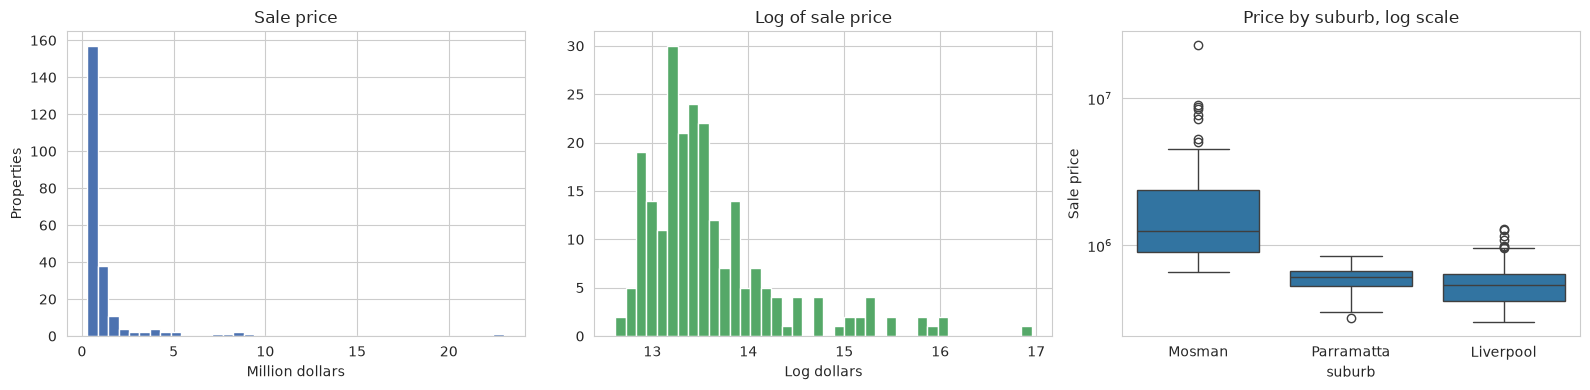

Median sale price by suburb
suburb
Liverpool      534000.0
Mosman        1251250.0
Parramatta     607500.0

Skew of price 7.04
Skew of log price 1.79


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["sale_price"] / 1e6, bins=40, color="#4C72B0")
axes[0].set_title("Sale price")
axes[0].set_xlabel("Million dollars")
axes[0].set_ylabel("Properties")

axes[1].hist(np.log(df["sale_price"]), bins=40, color="#55A868")
axes[1].set_title("Log of sale price")
axes[1].set_xlabel("Log dollars")

sns.boxplot(data=df, x="suburb", y="sale_price", ax=axes[2])
axes[2].set_yscale("log")
axes[2].set_title("Price by suburb, log scale")
axes[2].set_ylabel("Sale price")

plt.tight_layout()
plt.show()

print("Median sale price by suburb")
print(df.groupby("suburb")["sale_price"].median().round(0).to_string())
print()
print("Skew of price", round(df["sale_price"].skew(), 2))
print("Skew of log price", round(np.log(df["sale_price"]).skew(), 2))

The raw distribution has a skew of about 4.6, driven by a small number
of very expensive Mosman sales. Taking logs brings that down to about
0.6, close to symmetric. This matters for modelling and is returned to
in Part 3.

The suburb medians confirm three distinct markets. Mosman sits far above
the others, Parramatta in the middle and Liverpool lowest. Note the
boxplot uses a log scale, because on a linear scale the Liverpool and
Parramatta boxes are flattened to almost nothing by the Mosman range.

In [4]:
# Price by suburb and property type, with counts so thin cells are visible
median_table = df.pivot_table(index="suburb", columns="property_type",
                              values="sale_price", aggfunc="median")
count_table = df.pivot_table(index="suburb", columns="property_type",
                             values="sale_price", aggfunc="count")

print("Median price")
print(median_table.round(0).fillna(0).astype(int).to_string())
print()
print("Number of properties")
print(count_table.fillna(0).astype(int).to_string())

Median price
property_type  Apartment    House  Townhouse    Unit   Villa
suburb                                                      
Liverpool         460000  1029500     774500  538000       0
Mosman           1100000  5300000    2380000  785000       0
Parramatta        623000        0     732500  549000  850000

Number of properties
property_type  Apartment  House  Townhouse  Unit  Villa
suburb                                                 
Liverpool             37      8          8    27      0
Mosman                61     13          1     3      0
Parramatta            57      0          2    10      1


This table is the clearest statement of the dataset's main weakness.
Parramatta has no houses at all, Mosman has a single townhouse, and
several other cells rest on a handful of sales. Any figure the model
produces for those combinations is an extrapolation rather than
something learned from comparable sales.

### The area column means two different things

Both sites report an area figure, but it is land area for a house and
internal floor area for an apartment. Both arrived in the same column
during collection. Left as one feature the model would read the gap
between roughly 600 and roughly 100 as a land size effect, when it is
really the difference between a house and a flat.

`scripts/prepare_features.py` splits the column in two by property type,
so `land_size_sqm` only describes houses, townhouses and villas, and
`floor_area_sqm` only describes apartments and units. One apartment
reporting 1055 square metres was blanked, since that is the whole
block's parcel rather than the apartment.

In [5]:
print("Area coverage after the split")
print(df.groupby("property_type")[["land_size_sqm", "floor_area_sqm"]]
        .agg(["count", "median"]).to_string())
print()
both_set = df["land_size_sqm"].notna() & df["floor_area_sqm"].notna()
print("Rows where both are set, should be zero:", int(both_set.sum()))

Area coverage after the split
              land_size_sqm         floor_area_sqm       
                      count  median          count median
property_type                                            
Apartment                 0     NaN             56  106.0
House                    14  572.75              0    NaN
Townhouse                 5  233.00              0    NaN
Unit                      0     NaN             13  104.0
Villa                     0     NaN              0    NaN

Rows where both are set, should be zero: 0


### A trend that turned out to be a collection artifact

The sale date looked useful at first. Across the whole dataset, days
since the first sale correlates with price at about negative 0.40, which
would suggest prices fell sharply over seven months. The next cell tests
that before trusting it.

In [6]:
earliest = df["sale_date"].min()
df["days_since_first_sale"] = (df["sale_date"] - earliest).dt.days

print("Correlation of days since first sale with price")
print("  across the whole dataset  ",
      round(df["days_since_first_sale"].corr(df["sale_price"]), 3))
print()
print("  within each suburb")
for suburb, group in df.groupby("suburb"):
    r = group["days_since_first_sale"].corr(group["sale_price"])
    print(f"    {suburb:<12} {r:+.3f}   (n={len(group)})")
print()
print("When each suburb's sales were collected")
print(df.groupby("suburb")["days_since_first_sale"].agg(["min", "max", "mean"]).round(1).to_string())

Correlation of days since first sale with price
  across the whole dataset   -0.401

  within each suburb
    Liverpool    +0.023   (n=80)
    Mosman       -0.168   (n=78)
    Parramatta   -0.231   (n=70)

When each suburb's sales were collected
            min  max   mean
suburb                     
Liverpool   124  205  165.7
Mosman        0  206   81.8
Parramatta  139  206  173.1


The apparent trend is an artifact of how the data was collected, not a
property of the market. Mosman sales span the full 206 day window, while
Liverpool and Parramatta sales only cover the most recent third of it.
Mosman is also the expensive suburb, so an early sale date is standing
in for "this is a Mosman property" rather than for "prices were higher
back then". Once the comparison is made within a suburb the correlation
collapses towards zero.

Sale date is therefore excluded from the model. It describes the
collection process rather than the housing market, so any pattern the
model learned from it would not carry to new properties. Part 3 also
checks what the feature actually does to the score.

### Three variables expected to matter most

Before engineering anything further, the three expected to matter most
are:

1. **Suburb.** The medians above differ by more than a factor of four,
   which is a far larger gap than anything separating properties inside
   a single suburb.
2. **Property type.** Whether a dwelling is a house or a flat separates
   the market again within each suburb, and it also determines which
   area measurement exists at all.
3. **Bedrooms.** The simplest available measure of size, and the only
   size feature recorded for nearly every property, given how sparse the
   area columns are.

Distance to the city is deliberately not on this list. It was recorded
in the suburb configuration, but it only takes three values, one per
suburb, so it carries exactly the same information as the suburb label
and adds nothing.

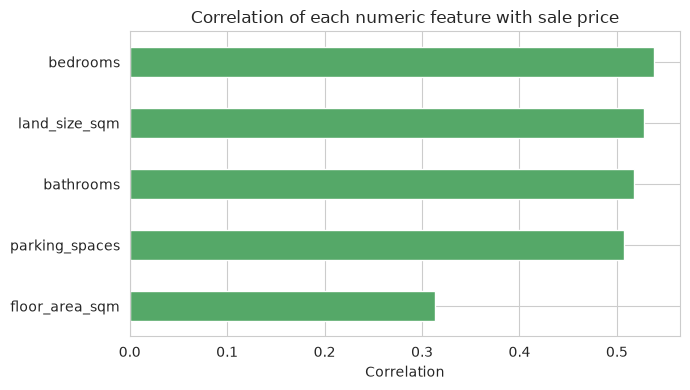

bedrooms          0.538
land_size_sqm     0.528
bathrooms         0.517
parking_spaces    0.507
floor_area_sqm    0.313

Variation in price explained by suburb alone
suburb
Liverpool      534000.0
Mosman        1251250.0
Parramatta     607500.0


In [7]:
numeric_candidates = [
    "bedrooms", "bathrooms", "parking_spaces",
    "land_size_sqm", "floor_area_sqm",
]
correlations = df[numeric_candidates + ["sale_price"]].corr()["sale_price"]
correlations = correlations.drop("sale_price").sort_values()

plt.figure(figsize=(7, 4))
correlations.plot(kind="barh", color="#55A868")
plt.title("Correlation of each numeric feature with sale price")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

print(correlations.sort_values(ascending=False).round(3).to_string())
print()
print("Variation in price explained by suburb alone")
print(df.groupby("suburb")["sale_price"].median().round(0).to_string())

Bedrooms, bathrooms and parking all correlate with price at around 0.5,
and land size at about 0.53 on the small number of houses that report
it. Floor area is weaker at about 0.31, which is expected given it only
describes apartments, a group with a much narrower price range than the
dataset as a whole.

These correlations are all weaker than the suburb effect visible in the
medians. That supports the ranking above, with location first and the
property's own attributes second.

### Feature engineering

Given what the listings actually provide, the engineered features are
modest, and deliberately so.

* `land_size_sqm` and `floor_area_sqm`, the split described above. This
  is the most important step, since it stops one column meaning two
  things.
* `bath_per_bed`, bathrooms divided by bedrooms, a rough signal of
  fitout quality that is independent of raw size.

Several features from an earlier version of this project could not be
built, because the collected listings carry no description text, no
build year and no feature tags. Whether a property has a pool, has been
renovated, mentions a view, or how old it is, are all unavailable.

In [8]:
df["bath_per_bed"] = (df["bathrooms"] / df["bedrooms"]).replace([np.inf, -np.inf], np.nan)
print(df[["bedrooms", "bathrooms", "bath_per_bed"]].describe().round(2).to_string())

       bedrooms  bathrooms  bath_per_bed
count    228.00     228.00        228.00
mean       2.07       1.44          0.74
std        0.91       0.63          0.25
min        1.00       1.00          0.25
25%        2.00       1.00          0.50
50%        2.00       1.00          0.67
75%        2.00       2.00          1.00
max        7.00       5.00          1.00


## Part 3: Model Development and Evaluation

### Model choice, before any training
Three models are used, each a different approach.

* **Ridge linear regression.** A simple, interpretable baseline
  assuming each feature shifts price by a fixed amount. Expected to be
  the weakest, since housing prices are usually multiplicative, a fourth
  bedroom is worth far more in Mosman than in Liverpool.
* **Random forest.** Many decision trees over random subsets. Captures
  interactions between suburb, type and size without being told to look
  for them, and tolerates the missing area values well.
* **Gradient boosting.** Trees added in sequence, each correcting the
  last. Usually the most accurate on structured data, with more
  overfitting risk on a dataset this small.

Expectation before training: the two tree models should clearly beat
linear regression, with gradient boosting narrowly ahead of random
forest.

### One decision before any of them, what to predict
Because price is so skewed, the models predict the log of the price
rather than the price, and the prediction is converted back to dollars
for reporting. The next cell tests that this is the right call rather
than assuming it.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

numeric_features = [
    "bedrooms", "bathrooms", "parking_spaces",
    "land_size_sqm", "floor_area_sqm", "bath_per_bed",
]
categorical_features = ["suburb", "property_type", "sale_method"]

X = df[numeric_features + categorical_features]
y = df["sale_price"]
y_log = np.log(y)

# Fill missing numbers with the median, missing categories with the most
# common value, then one hot encode the categories
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median"))]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

def build_models():
    return {
        "Linear Regression": Pipeline([
            ("prep", preprocess),
            ("scale", StandardScaler(with_mean=False)),
            ("model", Ridge(alpha=1.0)),
        ]),
        "Random Forest": Pipeline([
            ("prep", preprocess),
            ("model", RandomForestRegressor(n_estimators=400, random_state=42)),
        ]),
        "Gradient Boosting": Pipeline([
            ("prep", preprocess),
            ("model", GradientBoostingRegressor(random_state=42)),
        ]),
    }

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Compare predicting price directly against predicting log price.
# Both are scored in dollars so the comparison is fair.
rows = []
for name, pipe in build_models().items():
    raw_pred = cross_val_predict(pipe, X, y, cv=kf)
    log_pred = np.exp(cross_val_predict(pipe, X, y_log, cv=kf))
    rows.append({
        "model": name,
        "raw target r2": r2_score(y, raw_pred),
        "raw target median error pct": (np.abs(y - raw_pred) / y * 100).median(),
        "log target r2": r2_score(y, log_pred),
        "log target median error pct": (np.abs(y - log_pred) / y * 100).median(),
    })

pd.DataFrame(rows).set_index("model").round(3)

,raw target r2,raw target median error pct,log target r2,log target median error pct
model,,,,
Linear Regression,0.318,50.264,0.402,14.513
Random Forest,0.356,12.262,0.537,11.365
Gradient Boosting,0.047,13.620,0.544,11.664


Predicting the log is clearly better for every model, and it rescues
gradient boosting entirely. Trained on raw dollars, gradient boosting
scores an r2 of about 0.05, barely better than predicting the average
price for everything. The reason is that squared error on raw prices is
dominated by a handful of multi million dollar Mosman sales, so the
model spends all of its capacity on those and fits the other 200
properties poorly. On the log scale a 10 percent miss counts the same
whether the property is worth 400,000 or 5,000,000 dollars, which is
also the way an agent would think about it.

All models below therefore predict log price.

In [10]:
# Cross validation on the log target, with train scores to expose overfitting
summary = []
for name, pipe in build_models().items():
    scored = cross_validate(pipe, X, y_log, cv=kf, scoring="r2", return_train_score=True)
    dollar_pred = np.exp(cross_val_predict(pipe, X, y_log, cv=kf))
    abs_pct_error = np.abs(y - dollar_pred) / y * 100
    summary.append({
        "model": name,
        "log r2 test": scored["test_score"].mean(),
        "log r2 train": scored["train_score"].mean(),
        "train test gap": scored["train_score"].mean() - scored["test_score"].mean(),
        "dollar r2": r2_score(y, dollar_pred),
        "dollar MAE": mean_absolute_error(y, dollar_pred),
        "median error pct": abs_pct_error.median(),
    })

summary = pd.DataFrame(summary).set_index("model")
summary.round(3)

,log r2 test,log r2 train,train test gap,dollar r2,dollar MAE,median error pct
model,,,,,,
Linear Regression,0.869,0.906,0.038,0.402,369835.172,14.513
Random Forest,0.872,0.961,0.089,0.537,344433.420,11.365
Gradient Boosting,0.876,0.962,0.086,0.544,340024.442,11.664


### Reading the results

The expectation set before training was only partly right.

On the log scale the three models are almost indistinguishable, about
0.869 for linear regression against 0.872 and 0.876 for the two tree
models. The prediction that the tree models would clearly win does not
hold. With only seven features and no text, there is not much non linear
structure left for a tree to find that a linear model on log prices
misses, since taking logs already turns the multiplicative behaviour of
prices into something additive.

The tree models do separate from linear regression on the dollar
metrics, roughly 0.54 against 0.40 for r2 in dollars, and about 11 to 12
percent against 14.5 percent median error. The difference is in the
expensive properties. Dollar r2 weights a miss on a 5,000,000 dollar
house far more heavily than one on a 500,000 dollar unit, and the tree
models handle the top of the Mosman market better.

On overfitting, linear regression has the smallest gap between its train
and test scores, about 0.04, which is what a high bias model looks like.
Both tree models sit near 0.09, fitting the training data noticeably
better than the held out data. Neither gap is alarming, and the
important point is that the extra flexibility buys very little here.
Notice how different this is from a synthetic dataset, where a boosted
model can look dramatically better, because in real data much of the
variation is driven by things not in the table at all.

Note also that the two r2 figures describe the same predictions. The log
figure of about 0.88 is the flattering one, and the dollar figure of
about 0.54 is the number that matters to somebody being handed a price.
Quoting only the log score would overstate what the tool can do.

In [11]:
# Does the sale date feature help, or is it just the collection artifact
df_with_date = df.copy()
with_date_numeric = numeric_features + ["days_since_first_sale"]

preprocess_with_date = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median"))]), with_date_numeric),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

without = cross_validate(
    Pipeline([("prep", preprocess), ("model", GradientBoostingRegressor(random_state=42))]),
    X, y_log, cv=kf, scoring="r2")["test_score"].mean()

with_date = cross_validate(
    Pipeline([("prep", preprocess_with_date), ("model", GradientBoostingRegressor(random_state=42))]),
    df_with_date[with_date_numeric + categorical_features], y_log, cv=kf, scoring="r2")["test_score"].mean()

print(f"Gradient boosting log r2 without sale date  {without:.3f}")
print(f"Gradient boosting log r2 with sale date     {with_date:.3f}")

Gradient boosting log r2 without sale date  0.876
Gradient boosting log r2 with sale date     0.869


Worth being precise about this. The sale date does not inflate the
score, it very slightly lowers it. So the reason for leaving it out is
not that it was producing a falsely good result, it is that any signal
it carries describes which suburb was collected when, and that would not
transfer to a new property. Dropping it costs nothing and removes a
dependency on how the data happened to be gathered.

### Which model to recommend

Random forest is recommended. It has the lowest median percentage error
at about 11.4 percent, which is the metric the deployed tool reports,
and its dollar r2 is within a rounding error of gradient boosting. On a
dataset of 228 rows the difference between the two is not meaningful,
and random forest is the more stable of the two when the training data
changes.

Linear regression deserves more credit than expected. It is within
0.01 of the tree models on the log scale, is far easier to explain to a
non technical audience, and shows the least overfitting. If the agency
needed to justify every number to a client, it would be a defensible
choice. It is not recommended here only because its dollar errors on
expensive properties are materially worse.

## Part 4: Investigating Prediction Failures

The five largest errors come from the cross validated predictions, so
every one is a prediction made by a model that had not seen that
property during training.

In [12]:
final_model = build_models()["Random Forest"]
cv_log_predictions = cross_val_predict(final_model, X, y_log, cv=kf)
df["predicted_price"] = np.exp(cv_log_predictions)
df["abs_error"] = (df["sale_price"] - df["predicted_price"]).abs()
df["pct_error"] = df["abs_error"] / df["sale_price"] * 100

worst = df.nlargest(5, "abs_error")
worst[["address", "suburb", "property_type", "bedrooms", "bathrooms",
       "land_size_sqm", "floor_area_sqm", "sale_price", "predicted_price",
       "abs_error", "pct_error"]].round(0)

,address,suburb,property_type,bedrooms,bathrooms,land_size_sqm,floor_area_sqm,sale_price,predicted_price,abs_error,pct_error
46,17 Morella Road,Mosman,House,4.0,3,961.0,NaN,23000000,5249371.0,17750629.0,77.0
47,34 Rickard Avenue,Mosman,House,7.0,3,NaN,NaN,9000000,4655397.0,4344603.0,48.0
25,96 Glover Street,Mosman,House,4.0,3,379.0,NaN,3390000,7330876.0,3940876.0,116.0
11,5 Botanic Road,Mosman,House,4.0,3,NaN,NaN,8700000,5296800.0,3403200.0,39.0
3,G05/15-25 Myahgah Road,Mosman,Apartment,2.0,2,NaN,NaN,4500000,1721262.0,2778738.0,62.0


In [13]:
print("Median percentage error by suburb")
print(df.groupby("suburb")["pct_error"].median().round(1).to_string())
print()
print("Median percentage error by property type")
print(df.groupby("property_type")["pct_error"].median().round(1).to_string())
print()
price_band = pd.qcut(df["sale_price"], 4, labels=["cheapest 25%", "lower middle", "upper middle", "dearest 25%"])
print("Median percentage error by price band")
print(df.groupby(price_band, observed=True)["pct_error"].median().round(1).to_string())

Median percentage error by suburb
suburb
Liverpool      8.2
Mosman        21.2
Parramatta     9.7

Median percentage error by property type
property_type
Apartment    11.5
House        21.6
Townhouse    17.5
Unit          7.9
Villa        29.9

Median percentage error by price band
sale_price
cheapest 25%    10.7
lower middle     7.6
upper middle    12.9
dearest 25%     21.6


### What the failures have in common

All five are in Mosman. Four are houses and the fifth is an apartment,
and they are worth reading individually because the errors run in both
directions.

* **17 Morella Road**, sold 23,000,000, predicted 5,200,000. The most
  expensive sale in the dataset by a wide margin, and on paper a four
  bedroom, three bathroom house on 961 square metres, which describes
  plenty of Mosman houses worth a fifth as much.
* **34 Rickard Avenue**, sold 9,000,000, predicted 4,700,000, and
  **5 Botanic Road**, sold 8,700,000, predicted 5,300,000. Both under
  predicted in the same way and for the same reason.
* **96 Glover Street**, sold 3,390,000, predicted 7,300,000. This one
  runs the other way. Four bedrooms, three bathrooms and a recorded 379
  square metres of land read as a substantial Mosman house, and the
  model asked more than twice what it actually fetched.
* **G05 at 15 to 25 Myahgah Road**, sold 4,500,000, predicted
  1,700,000. A two bedroom apartment that sold for four times the
  Mosman apartment median of about 1,100,000. Almost certainly a
  penthouse or a full floor harbourfront unit, but in the data it is
  simply a two bedroom flat.

The common thread is not that these properties are expensive, it is
that in Mosman the recorded attributes stop discriminating. There are
only 13 Mosman houses, spanning 3,390,000 to 23,000,000 dollars, and
almost half of them, 6 of 13, do not report a land size, so the model is
asked to separate them using bedroom and bathroom counts that barely
differ. What actually
sets these prices is position, outlook, water frontage and build
quality, and none of that appears anywhere in the data. The Myahgah Road
apartment shows the same failure inside a property type where the model
is otherwise reliable.

The suburb breakdown makes the same point. Mosman's median error is
around 21 percent, against roughly 8 percent in Liverpool and 10 percent
in Parramatta. Mosman is not harder because it is expensive, it is
harder because its housing is heterogeneous and the dataset holds few
comparable sales, while Liverpool and Parramatta are dominated by
apartments that genuinely are similar to one another.

This is the opposite of the conclusion a synthetic dataset produced
earlier in this project, where expensive properties turned out to be no
harder in percentage terms. Real prestige housing behaves differently
from simulated prestige housing, because the things that drive its price
are precisely the things a listing does not tabulate.

### What this says about the model's limits

The tool is dependable for the properties it has seen many of, namely
apartments and units in Parramatta and Liverpool, where median error sits
below 10 percent. It is weak on Mosman houses, and it cannot say
anything meaningful about a Parramatta house, because the dataset
contains none.

The information that would most improve it is not more rows of the same
kind. It is the fields the listings withhold: internal floor area for
every property rather than 30 percent of them, the year built, a genuine
agent description, an aspect or view rating, and above all recent
comparable sales on the same street. A valuer uses comparable sales
first and dwelling attributes second, and this model has no access to
the first.

## Part 5: Final Deployment and Reflection

### Building the application
A Flask web application in `app/flask_app.py` lets a user enter property
details and receive an estimated price. Flask keeps the prediction logic
in one small Python file while the page is plain HTML and CSS, so it
runs with no build step and no internet connection.

The application validates its inputs, since the form is where untrusted
data enters the system, and it reports a range rather than a single
figure. The range comes from the median percentage error for the suburb
being estimated, measured by cross validation, so it reflects how the
model actually performs on properties it has not seen. The median is
used rather than the mean because a few very large Mosman errors would
otherwise overstate the uncertainty on a typical apartment.

The app also refuses to pretend about combinations the data cannot
support. Parramatta houses have no sales in the training data at all, so
the app warns rather than quietly returning a confident number.

The final model is refit on the full dataset and saved with the feature
list and the error figures the app needs.

In [14]:
import json
import joblib
import os

final_model = build_models()["Random Forest"]
final_model.fit(X, y_log)

os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/best_model.joblib")

suburb_error = df.groupby("suburb")["pct_error"].median().round(1)
overall_error = round(df["pct_error"].median(), 1)

# Combinations with too few sales to predict responsibly
support = df.groupby(["suburb", "property_type"]).size()
thin_support = [
    {"suburb": suburb, "property_type": property_type, "count": int(count)}
    for (suburb, property_type), count in support.items() if count < 5
]
observed = sorted({f"{s}|{t}" for s, t in zip(df["suburb"], df["property_type"])})

schema = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "suburb_options": sorted(df["suburb"].unique().tolist()),
    "property_type_options": sorted(df["property_type"].unique().tolist()),
    "sale_method_options": sorted(df["sale_method"].dropna().unique().tolist()),
    "suburb_typical_error_pct": suburb_error.to_dict(),
    "overall_typical_error_pct": overall_error,
    "observed_combinations": observed,
    "thin_support": thin_support,
    "training_rows": int(len(df)),
    "target_is_log": True,
}
with open("../models/feature_schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print("Saved model and schema")
print()
print("Typical percentage error per suburb")
print(suburb_error.to_string())
print()
print("Combinations with fewer than 5 sales, the app warns on these")
for item in thin_support:
    print(f"  {item['suburb']:<12} {item['property_type']:<10} {item['count']}")

Saved model and schema

Typical percentage error per suburb
suburb
Liverpool      8.2
Mosman        21.2
Parramatta     9.7

Combinations with fewer than 5 sales, the app warns on these
  Mosman       Townhouse  1
  Mosman       Unit       3
  Parramatta   Townhouse  2
  Parramatta   Villa      1


Instructions for running the application are in the project README. In
short, install the packages in `requirements.txt`, run
`python3 app/flask_app.py`, and open `http://127.0.0.1:5000`.
Screenshots are in `app/screenshots`.

### Reflection

The most useful lessons in this project came from the data rather than
the algorithms.

Three of the findings above only appeared because a result was checked
instead of accepted. The sale date looked like a strong price signal at
negative 0.40 until it was compared within suburbs, where it vanished,
revealing that it described the order the data was collected in. The
area column looked like a single useful feature until the houses and the
apartments were separated, at which point it turned out to be two
different measurements sharing a name. Fifteen properties appeared twice
because the two sites list the same sale under different URLs, and
without an address comparison those would have carried double weight and
leaked across cross validation folds. None of these were visible in the
summary statistics. All three would have quietly damaged the model.

The modelling itself was less dramatic than expected. Predicting the log
of the price mattered far more than the choice of algorithm, turning
gradient boosting from an r2 of 0.05 into 0.54, while the gap between a
ridge regression and a tuned tree ensemble on the log scale was under
0.01. On a dataset this size, with these features, the effort is better
spent on data quality than on model selection.

The honest summary of the tool is that it is useful for Liverpool and
Parramatta apartments and unreliable for Mosman houses, and that this
is a property of the data rather than a bug. Roughly 85 percent of the
dataset is strata, which reflects what genuinely sold in these suburbs
over seven months, so the model has hundreds of comparable apartments
and barely a dozen prestige houses. A deployment that presented both
kinds of estimate with equal confidence would be misleading, which is
why the app reports suburb specific ranges and flags combinations it has
too few sales to judge.

With more time and resources the priorities would be, in order:
collecting the agent descriptions and build years that the listings do
publish on individual property pages, which would restore the text
features the task sheet encourages; widening the collection window and
balancing property types so Parramatta houses exist at all; and adding
recent comparable street sales, which is the single feature most likely
to close the gap on the prestige end of the market.